# 🛒 Big Data with PySpark — Retail Analytics Lab
### Student Practice Notebook | RetailCo E-Commerce Dataset

---

## 📋 How to Use This Notebook

- Cells marked **`# ✏️ YOUR CODE HERE`** are yours to complete.
- Cells marked **`# FILL IN THE BLANK`** have partial code — replace every `___` with the correct value.
- **Run all cells in order** — later exercises depend on earlier ones.
- Use the **Cheat Sheet** (last section) whenever you get stuck.

---

**Topics covered:**
- ✅ Part 1 — PySpark Fundamentals (SparkSession, RDDs, SQL)
- ✅ Part 2 — Data Cleaning (schemas, Parquet, UDFs, caching, joins)
- ✅ Part 3 — Feature Engineering (scaling, encoding, dates, splits)
- ✅ Part 4 — Machine Learning (classification, regression, NLP, pipelines)


## ⚙️ Step 0 — Dataset Setup

> **Run this cell once** before starting. It generates all datasets used throughout the lab.


In [ ]:
# ============================================================
# 📦 DATASET SETUP — Run this ONCE before starting the lab
# ============================================================
import os, requests, gzip, shutil, zipfile
import pandas as pd
import numpy as np

os.makedirs('data', exist_ok=True)
np.random.seed(42)

# ── PART 1 datasets ──────────────────────────────────────────
customers = [f'C{i:04d}' for i in range(1, 501)]
products  = [f'P{i:03d}' for i in range(1, 101)]
lines = [
    f"{np.random.choice(customers)},{np.random.choice(products)},{round(np.random.uniform(5,500),2)},2024-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}"
    for _ in range(10000)
]
with open('data/transactions.txt','w') as f: f.write('\n'.join(lines))

words   = ['great','terrible','love','broken','fast','slow','cheap','quality','refund','perfect','damaged','amazing','awful','recommend','return']
reviews = [' '.join(np.random.choice(words, np.random.randint(5,20))) for _ in range(5000)]
with open('data/product_reviews.txt','w') as f: f.write('\n'.join(reviews))

df_r = pd.DataFrame({'userId':np.random.randint(1,1001,50000),'movieId':np.random.randint(1,5001,50000),'rating':np.random.choice([1.0,2.0,3.0,4.0,5.0],50000)})
df_r.to_csv('data/product_ratings.csv', index=False, header=False)

df_c = pd.DataFrame({'recency_days':np.random.randint(1,365,2000),'total_spend':np.random.randint(10,5000,2000)})
df_c.to_csv('data/customer_features.tsv', sep='\t', index=False, header=False)

# ── PART 2 datasets ──────────────────────────────────────────
n = 20000
df_o = pd.DataFrame({'order_id':[f'O{i:06d}' for i in range(n)],'customer_id':[f'C{np.random.randint(1,5001):05d}' for _ in range(n)],'category':np.random.choice(['Electronics','Clothing','Books','Home','Sports'],n),'total_amount':np.round(np.random.uniform(10,800,n),2),'country_code':np.random.choice(['BR','US','DE','FR','GB'],n),'order_date':pd.date_range('2022-01-01',periods=n,freq='1h').astype(str)})
df_o.to_csv('data/orders.csv', index=False)

df_s = pd.DataFrame({'shipment_id':[f'S{i:06d}' for i in range(n)],'order_id':df_o['order_id'],'carrier':np.random.choice(['FedEx','UPS','DHL','Correios'],n),'origin_city':np.random.choice(['Sao Paulo','New York','Berlin'],n),'dest_city':np.random.choice(['Rio de Janeiro','Chicago','Paris'],n),'weight_kg':np.round(np.random.uniform(0.1,30,n),2),'transit_days':np.random.randint(1,15,n)})
df_s.to_csv('data/shipments.csv', index=False)

warehouses=[f'WH{i:03d}' for i in range(1,21)]
rows=['# Open Images Annotation File','# Format: warehouse\tsku\twidth\theight\tcategories']
for _ in range(5000):
    wh=np.random.choice(warehouses); sku=f'SKU{np.random.randint(1,1001):04d}'
    w,h=np.random.randint(100,1000),np.random.randint(100,1000)
    cats='|'.join(np.random.choice(['Electronics','Clothing','Books','Toys'],np.random.randint(1,4),replace=False))
    rows.append(f'{wh}\t{sku}\t{w}\t{h}\t{cats}')
with gzip.open('data/product_annotations.csv.gz','wt') as f: f.write('\n'.join(rows))

# ── PART 3 datasets ──────────────────────────────────────────
n2=30000
df_p3=pd.DataFrame({'product_id':[f'P{i:05d}' for i in np.random.randint(1,5001,n2)],'product_name':np.random.choice(['Widget Alpha','Gadget Pro','Blue Widget','Smart Tool'],n2),'CATEGORY':np.random.choice(['Electronics','Clothing','Books','Home','Sports'],n2),'LIST_PRICE':np.round(np.random.uniform(5,500,n2),2),'SALE_PRICE':np.round(np.random.uniform(5,500,n2),2),'COST_PRICE':np.round(np.random.uniform(2,200,n2),2),'DISCOUNT_AMT':np.round(np.random.uniform(0,100,n2),2),'DISCOUNT_PCT':np.round(np.random.uniform(0,0.5,n2),3),'UNITS_SOLD':np.random.randint(1,200,n2),'PAGE_VIEWS':np.random.randint(10,5000,n2),'REVIEW_SCORE':np.round(np.random.uniform(1,5,n2),1),'RETURN_RATE':np.round(np.random.uniform(0,0.3,n2),3),'DAYS_IN_STOCK':np.random.randint(1,365,n2),'LAUNCH_DATE_STR':pd.date_range('2020-01-01',periods=n2,freq='1h').astype(str),'longitude':np.round(np.random.uniform(-10,30,n2),5),'latitude':np.round(np.random.uniform(35,60,n2),5),'SHIPPING_OPTIONS':np.random.choice(['Free Shipping, Standard','Express, Standard','Standard'],n2)})
df_p3.to_parquet('data/RetailCo_Sales.parq', index=False)

dates=pd.date_range('2022-01-01','2024-12-31',freq='W')
df_pr=pd.DataFrame({'UPDATE_DATE':dates,'product_id':np.random.choice([f'P{i:04d}' for i in range(1,101)],len(dates)),'price':np.round(np.random.uniform(10,300,len(dates)),2)})
df_pr.to_csv('data/price_updates.csv', index=False)

# ── PART 4 datasets ──────────────────────────────────────────
n3=25000
df_ml=pd.DataFrame({'order_id':[f'O{i:06d}' for i in range(n3)],'carrier':np.random.choice(['FedEx','UPS','DHL','Correios'],n3),'origin_zone':np.random.choice(['Zone_A','Zone_B','Zone_C','Zone_D'],n3),'distance_miles':np.round(np.random.uniform(50,3000,n3),1),'weight_kg':np.round(np.random.uniform(0.1,30,n3),2),'delay_days':np.random.randint(0,10,n3),'priority_score':np.random.randint(1,6,n3),'warehouse_congestion':np.round(np.random.uniform(0,1,n3),2),'day_of_week':np.random.randint(1,8,n3)})
df_ml.to_csv('data/shipment_records.csv', index=False)

pos=['great product love it highly recommend amazing quality fast shipping perfect'.split() for _ in range(2500)]
neg=['broken terrible waste refund slow cheap damaged awful do not buy return'.split() for _ in range(2500)]
rows2=[]
for i,w in enumerate(pos): rows2.append(f'{i};{" ".join(np.random.choice(w,np.random.randint(5,15)))};1')
for i,w in enumerate(neg): rows2.append(f'{i+2500};{" ".join(np.random.choice(w,np.random.randint(5,15)))};0')
with open('data/product_reviews.csv','w') as f: f.write('\n'.join(rows2))

print('✅ All datasets ready in data/')
for fname in sorted(os.listdir('data')):
    fpath=os.path.join('data',fname)
    if os.path.isfile(fpath): print(f'  {fname:45s} {os.path.getsize(fpath)/1024:8.1f} KB')


✅ All datasets ready in data/
  RetailCo_Sales.parq                             1625.2 KB
  customer_features.tsv                             16.6 KB
  orders.csv                                      1027.5 KB
  price_updates.csv                                  3.7 KB
  product_annotations.csv.gz                        43.7 KB
  product_ratings.csv                              618.8 KB
  product_reviews.csv                              336.5 KB
  product_reviews.txt                              408.8 KB
  shipment_records.csv                            1071.3 KB
  shipments.csv                                    937.8 KB
  transactions.txt                                 280.3 KB


## ⚙️ Step 1 — Install & Import PySpark


In [ ]:
!pip install pyspark --quiet


---
# 🔵 Part 1 — PySpark & Big Data Fundamentals
---


## Section 1.1 — SparkSession & SparkContext

### 🧠 Concept
- **SparkSession** (`spark`) — the modern entry point to all PySpark operations (Spark 2.0+).
- **SparkContext** (`sc`) — the older, lower-level entry point accessed via `spark.sparkContext`.

### 🎯 Exercise A — Fill in the blanks to create a SparkSession
Replace every `___` with the correct value.


In [ ]:
# FILL IN THE BLANK
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Retail Analytics Lab") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")   # suppress noisy INFO logs
print("✅ SparkSession ready! Version:", spark.version)


✅ SparkSession ready! Version: 4.0.2


### 🎯 Exercise B — Write from scratch
Assign `sc = spark.sparkContext`, then print:
1. The Spark version
2. The master URL
3. The application name


In [ ]:
sc = spark.sparkContext

print('Spark version:', sc.version)
print('Python version:', sc.pythonVer)
print('Master URL:', sc.master)
print('App name:', sc.appName)


Spark version: 4.0.2
Python version: 3.12
Master URL: local[*]
App name: Retail Analytics Lab


## Section 1.2 — RDD Basics

An **RDD** (Resilient Distributed Dataset) is a fault-tolerant, distributed collection.

| Method | Description |
|---|---|
| `sc.parallelize(collection)` | Create RDD from a Python list/range |
| `sc.textFile(path)` | Create RDD from a text file (1 line = 1 element) |
| `.count()` | Count total elements |
| `.take(n)` | Return first n elements |

### 🎯 Exercise A — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
# Create an RDD from product IDs 1 to 200
products_rdd = sc.parallelize(range(1, 201))

print('Type:', type(products_rdd))
print('First 5:', products_rdd.take(5))   # take first 5
print('Total:',   products_rdd.count())       # count all elements


Type: <class 'pyspark.core.rdd.PipelinedRDD'>
First 5: [1, 2, 3, 4, 5]
Total: 200


### 🎯 Exercise B — Write from scratch
Load `data/transactions.txt` into an RDD called `transaction_rdd`.
Print: its type, total number of lines, and the first 3 lines.
Then reload it requesting at least **8 partitions** and print the partition count.


In [ ]:
transaction_rdd = sc.textFile('data/tramsaction.txt')

print('Type:', type(products_rdd))
print('First 5:', products_rdd.take(3))   # take first 3
print('Total:',   products_rdd.count())       # count all elements


Type: <class 'pyspark.core.rdd.PipelinedRDD'>
First 5: [1, 2, 3]
Total: 200


## Section 1.3 — Lambda Functions: `map` and `filter`

- `map(lambda x: ...)` — transforms **every** element
- `filter(lambda x: ...)` — keeps elements where the condition is **True**

### 🎯 Exercise A — Fill in the blanks (apply a 15% discount)


In [ ]:
# FILL IN THE BLANK
prices = [29.99, 49.99, 9.99, 199.99, 74.99]

# Apply 15% discount: new_price = price * 0.85, rounded to 2 decimals
discounted = list(map(lambda price: round(price * 0.85, 2), prices))

print('Original:  ', prices)
print('Discounted:', discounted)


Original:   [29.99, 49.99, 9.99, 199.99, 74.99]
Discounted: [25.49, 42.49, 8.49, 169.99, 63.74]


### 🎯 Exercise B — Write from scratch
Given `order_values = [23.50, 115.00, 88.99, 200.00, 45.50, 130.75, 9.99]`,
use `filter` to find all orders **over $100** (eligible for free shipping).
Print the qualifying orders.


In [ ]:
# ✏️  YOUR CODE HERE
order_values = [23.50, 115.00, 88.99, 200.00, 45.50, 130.75, 9.99]

free_shipping = list(filter(lambda x: x > 100, order_values))

print('All order values:         ', order_values)
print('Qualifying orders (>$100):', free_shipping)

All order values:          [23.5, 115.0, 88.99, 200.0, 45.5, 130.75, 9.99]
Qualifying orders (>$100): [115.0, 200.0, 130.75]


## Section 1.4 — RDD Transformations: `map`, `filter`, `flatMap`

| Transformation | What it does |
|---|---|
| `map(f)` | One output per input |
| `filter(f)` | Keep elements where `f` is True |
| `flatMap(f)` | 0 or many outputs per input (flattens the result) |

> 💡 **Key idea:** Transformations are **lazy** — nothing runs until an *action* (like `.collect()` or `.count()`) is called.

### 🎯 Exercise A — Fill in the blanks (map: reorder quantities)


In [ ]:
# FILL IN THE BLANK
stock_rdd   = sc.parallelize(range(1, 11))
reorder_rdd = stock_rdd.map(lambda x: x ** 2)   # square each stock level

for level, reorder in zip(stock_rdd.collect(), reorder_rdd.collect()):  # trigger execution
    print(f'Stock {level:2d} → Reorder qty: {reorder}')


Stock  1 → Reorder qty: 1
Stock  2 → Reorder qty: 4
Stock  3 → Reorder qty: 9
Stock  4 → Reorder qty: 16
Stock  5 → Reorder qty: 25
Stock  6 → Reorder qty: 36
Stock  7 → Reorder qty: 49
Stock  8 → Reorder qty: 64
Stock  9 → Reorder qty: 81
Stock 10 → Reorder qty: 100


### 🎯 Exercise B — Write from scratch
Using `sc.textFile('data/product_reviews.txt')`:
1. Load reviews into an RDD called `reviews_rdd`
2. **Filter** for lines containing the word `'refund'` (case-insensitive)
3. **flatMap** to split every review into individual words
4. Print: total refund-related reviews, first 3 such reviews, total word count across ALL reviews


In [ ]:
# ✏️  YOUR CODE HERE
reviews_rdd    = sc.textFile('data/product_reviews.txt')
refund_reviews = reviews_rdd.filter(lambda line: 'refund' in line.lower())

print('Total reviews mentioning refund:', refund_reviews.count())
for line in refund_reviews.take(3):
    print(' -', line)
review_words = reviews_rdd.flatMap(lambda line: line.split())

print('Total words across all reviews:', review_words.count())
print('First 10 words:', review_words.take(10))

Total reviews mentioning refund: 2741
 - perfect slow return refund awful cheap return love cheap perfect recommend
 - fast fast refund quality great terrible amazing return
 - refund fast fast broken broken
Total words across all reviews: 59833
First 10 words: ['perfect', 'slow', 'return', 'refund', 'awful', 'cheap', 'return', 'love', 'cheap', 'perfect']


## Section 1.5 — Pair RDDs & Key-Value Operations

A **Pair RDD** contains `(key, value)` tuples.

| Operation | Purpose |
|---|---|
| `reduceByKey(f)` | Aggregate values with the same key |
| `sortByKey(ascending=False)` | Sort by key |
| `countByKey()` | Count values per key (returns a dict) |

### 🎯 Exercise A — Fill in the blanks (revenue per category)


In [ ]:
# FILL IN THE BLANK
sales_rdd = sc.parallelize([
    (1, 250.0), (2, 180.0), (1, 310.0),
    (3, 95.0),  (2, 220.0), (3, 150.0), (1, 75.0)
])

# Sum revenue per category using reduceByKey
revenue_by_cat = sales_rdd.reduceByKey(lambda x, y: x + y)

for cat, rev in revenue_by_cat.collect():
    print(f'Category {cat}: ${rev:.2f}')


Category 2: $400.00
Category 1: $635.00
Category 3: $245.00


### 🎯 Exercise B — Write from scratch
Using `revenue_by_cat` from Exercise A:
1. Sort the results **descending by revenue** (hint: swap key/value first, then `sortByKey`)
2. Count **how many transactions** each category has using `countByKey()` on `sales_rdd`
3. Print both results neatly


In [ ]:
revenue_sorted = revenue_by_cat \
    .map(lambda x: (x[1], x[0])) \
    .sortByKey(ascending=False)

for rev, cat in revenue_sorted.collect():
    print(f'  Category {cat}: ${rev:.2f}')

  Category 1: $635.00
  Category 2: $400.00
  Category 3: $245.00


## Section 1.6 — Word Count: The MapReduce Classic

Pipeline: `read → flatMap → filter → map → reduceByKey → sort → take`

### 🎯 Exercise — Fill in each blank step of the word count pipeline


In [ ]:
# FILL IN THE BLANK
stop_words = ['is','the','a','it','and','to','for','in','of']

base_rdd = sc.textFile('data/product_reviews.txt')

# Step 1: Split each line into words
words_rdd = base_rdd.flatMap(lambda line: line.split())           # flatMap + split

# Step 2: Remove stop words
words_clean = words_rdd.filter(lambda w: w.lower() not in stop_words) # filter

# Step 3: Create (word, 1) pairs
word_pairs = words_clean.map(lambda w: (w.lower(), 1))     # map

# Step 4: Sum counts per word
word_counts = word_pairs.reduceByKey(lambda x, y: x + y)         # reduceByKey

print('Total unique words:', word_counts.count())

# Step 5: Sort by frequency descending and show top 10
top_words = word_counts.map(lambda x: (x[1], x[0])).sortByKey(ascending=False)
print('\nTop 10 review keywords:')
for count, word in top_words.take(10):
    print(f'  {word}: {count}')


Total unique words: 15

Top 10 review keywords:
  perfect: 4098
  slow: 4068
  refund: 4036
  fast: 4019
  quality: 4005
  terrible: 3988
  awful: 3987
  broken: 3984
  love: 3980
  cheap: 3976


## Section 1.7 — From RDD to DataFrame

**DataFrames** add named columns, schema validation, and SQL support on top of RDDs.
They are **faster** than RDDs for structured data thanks to the Catalyst optimiser.

> ⚠️ **Never** call `.collect()` or `.toPandas()` on a large DataFrame — it pulls ALL data to the driver and will crash your machine. Always aggregate first!

### 🎯 Exercise A — Fill in the blanks (create DataFrame from RDD)


In [ ]:
# FILL IN THE BLANK
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, DateType

# Define an explicit schema for transactions.txt
tx_schema = StructType([
    StructField('customer_id',  StringType(),  True),   # string column
    StructField('order_id',     StringType(),  True),   # string column
    StructField('total_amount', DoubleType(),  True),   # decimal number
    StructField('order_date',   DateType(),  True),   # date
])

orders_df = spark.read.csv('data/transactions.txt', header=False, schema=tx_schema)

print('Rows:', orders_df.count())
orders_df.show(5)


Rows: 10000
+-----------+--------+------------+----------+
|customer_id|order_id|total_amount|order_date|
+-----------+--------+------------+----------+
|      C0103|    P052|       475.6|2024-11-08|
|      C0189|    P021|       82.23|2024-03-23|
|      C0331|    P075|      433.76|2024-04-08|
|      C0152|    P003|       15.19|2024-02-24|
|      C0492|    P030|      110.11|2024-12-21|
+-----------+--------+------------+----------+
only showing top 5 rows


### 🎯 Exercise B — Write from scratch
Using `orders_df`:
1. Select only `order_id`, `customer_id`, `order_date`, `total_amount` and drop duplicates
2. Filter for **high-value orders** (total_amount > 500) and **standard orders** (≤ 500)
3. Print the count of each group


In [ ]:
# ✏️  YOUR CODE HERE
orders_sub = orders_df.select('order_id', 'customer_id', 'order_date', 'total_amount')
orders_no_dup = orders_sub.dropDuplicates()

print(f'Before dedup: {orders_sub.count()} rows  |  After: {orders_no_dup.count()} rows')
orders_no_dup.show(10)

high_sql = spark.sql('SELECT * FROM orders WHERE total_amount > 500')
std_sql  = spark.sql('SELECT * FROM orders WHERE total_amount <= 500')

print(f'High-value (SQL): {high_sql.count()} rows')
print(f'Standard   (SQL): {std_sql.count()} rows')

Before dedup: 10000 rows  |  After: 10000 rows
+--------+-----------+----------+------------+
|order_id|customer_id|order_date|total_amount|
+--------+-----------+----------+------------+
|    P037|      C0099|2024-01-14|      464.52|
|    P072|      C0476|2024-09-07|       63.18|
|    P064|      C0296|2024-08-11|      289.36|
|    P078|      C0369|2024-05-17|       96.23|
|    P066|      C0376|2024-07-24|       67.19|
|    P052|      C0077|2024-12-11|      116.79|
|    P041|      C0482|2024-07-07|       180.5|
|    P043|      C0489|2024-01-19|      186.23|
|    P090|      C0096|2024-11-10|       94.53|
|    P023|      C0056|2024-11-09|      481.63|
+--------+-----------+----------+------------+
only showing top 10 rows
High-value (SQL): 0 rows
Standard   (SQL): 10000 rows


## Section 1.8 — Spark SQL

Steps: **register temp view** → **write SQL** → **get DataFrame back**

### 🎯 Exercise A — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
# Register orders_df as a SQL view called 'orders'
orders_df.createOrReplaceTempView('orders')

# Query: Top 10 customers by total spend (lifetime value)
top_customers = spark.sql('''
    SELECT customer_id, ROUND(SUM(total_amount), 2) AS lifetime_value
    FROM orders
    GROUP BY customer_id
    ORDER BY lifetime_value DESC
    LIMIT 10
''')
top_customers.show()


+-----------+--------------+
|customer_id|lifetime_value|
+-----------+--------------+
|      C0371|      10276.64|
|      C0447|       9914.23|
|      C0140|       9519.06|
|      C0476|        8812.4|
|      C0186|       8538.08|
|      C0089|       8494.26|
|      C0109|       8345.61|
|      C0106|       7979.25|
|      C0427|       7928.76|
|      C0231|       7921.87|
+-----------+--------------+



### 🎯 Exercise B — Write from scratch
Write a SQL query that computes **monthly revenue** — the total `total_amount` per month.
Hint: Use `TRUNC(order_date, 'MM')` to floor dates to the first of each month.
Sort by month ascending and display the result.


In [ ]:
# ✏️  YOUR CODE HERE
top_customers = spark.sql('''
    SELECT TRUNC(order_date, 'MM') AS Month , ROUND(SUM(total_amount), 2) AS monthly_revenue
    FROM orders
    GROUP BY Month
    ORDER BY monthly_revenue DESC
    LIMIT 10
''')
top_customers.show()


+----------+---------------+
|     Month|monthly_revenue|
+----------+---------------+
|2024-04-01|      229979.37|
|2024-10-01|      226450.38|
|2024-08-01|       216501.4|
|2024-07-01|      214929.58|
|2024-09-01|      213353.34|
|2024-05-01|      213044.85|
|2024-06-01|      211768.02|
|2024-12-01|      209350.48|
|2024-01-01|      205605.76|
|2024-11-01|      201879.06|
+----------+---------------+



## Section 1.9 — Visualisation with Pandas

> **Safe pattern:** Aggregate in Spark → `.toPandas()` on the small summary → plot with Matplotlib.

### 🎯 Exercise — Fill in the blanks


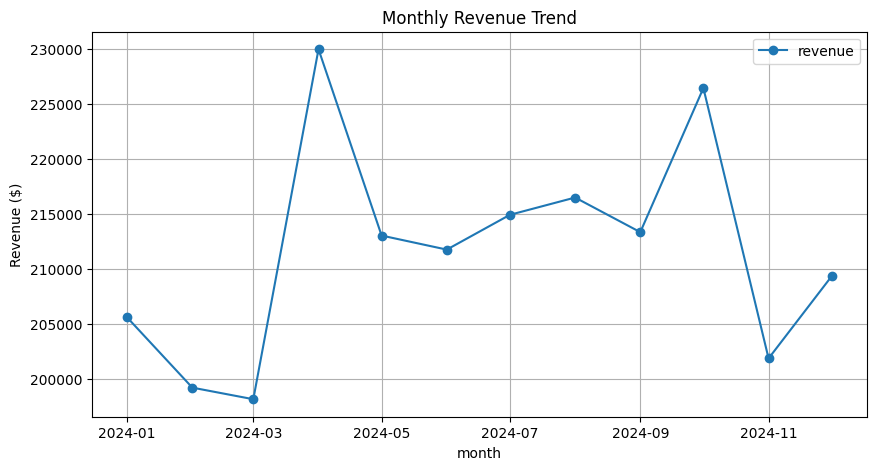

In [ ]:
# FILL IN THE BLANK
import matplotlib.pyplot as plt

# Step 1: Aggregate monthly revenue in Spark
monthly_rev = spark.sql('''
    SELECT TRUNC(order_date, 'MM') AS month,
           ROUND(SUM(total_amount), 2) AS revenue
    FROM orders
    GROUP BY month
    ORDER BY month
''')

# Step 2: Convert small summary to Pandas
rev_pd = monthly_rev.toPandas()

# Step 3: Plot
rev_pd.plot(kind='line', x='month', y='revenue', marker='o', figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.show()


## Section 1.10 — Intro to MLlib

PySpark's legacy **MLlib** (RDD-based) supports:

| Algorithm | Use Case |
|---|---|
| `ALS` | Collaborative filtering (recommendations) |
| `LogisticRegressionWithLBFGS` | Binary classification |
| `KMeans` | Customer segmentation |

### 🎯 Exercise A — Fill in the blanks (ALS Recommendation)


In [ ]:
# FILL IN THE BLANK
from pyspark.mllib.recommendation import ALS, Rating

ratings_raw = sc.textFile('data/product_ratings.csv')

def parse_rating(row):
    try:
        return Rating(int(row[0]), int(row[1]), float(row[2]))
    except ValueError:
        return None

ratings_final = ratings_raw.map(lambda l: l.split(',')).map(parse_rating).filter(lambda x: x is not None)

# 80/20 split
train_r, test_r = ratings_final.randomSplit([0.8, 0.2], seed=42)

# Train ALS with rank=10 latent factors
als_model = ALS.train(train_r, rank=10, iterations=10)

# Evaluate with MSE
actual    = test_r.map(lambda r: ((r[0], r[1]), r[2]))
predicted = als_model.predictAll(test_r.map(lambda r: (r[0], r[1]))).map(lambda r: ((r[0], r[1]), r[2]))
MSE = actual.join(predicted).map(lambda r: (r[1][0] - r[1][1])**2).mean()
print(f'ALS MSE = {MSE:.4f}')


ALS MSE = 24.7687


### 🎯 Exercise B — Write from scratch (KMeans Clustering)
Load `data/customer_features.tsv` (tab-separated: recency_days, total_spend) into an RDD.
Train a **KMeans** model with **k=4** and seed=42.
Print the 4 cluster centers.

```python
# Imports you'll need:
from pyspark.mllib.clustering import KMeans
```


Customers for clustering: 2000
  k=3  WSSSE=470,208,053
  k=4  WSSSE=283,254,129
  k=5  WSSSE=184,703,121
  k=6  WSSSE=136,156,487


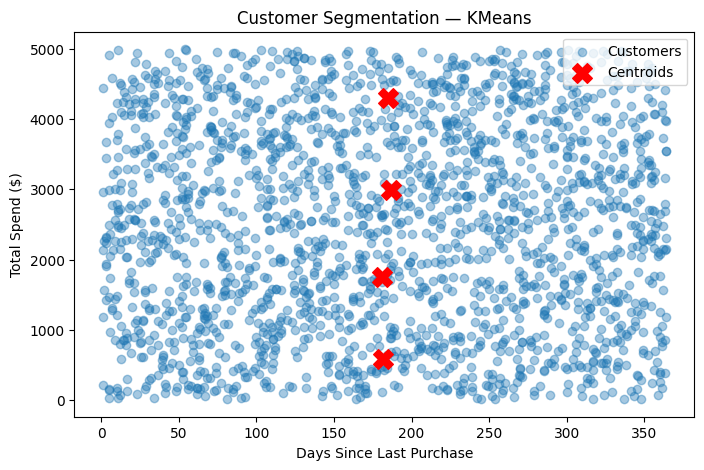

In [ ]:
# ✏️  YOUR CODE HERE
import pandas as pd
from pyspark.mllib.clustering import KMeans

# Fix: Use the correct path for customer features (TSV file)
file_path_cust = 'data/customer_features.tsv'

# Load 2D customer features: (recency_days, total_spend)
cust_raw  = sc.textFile(file_path_cust)
cust_feat = cust_raw.map(lambda x: x.split('\t')).map(lambda x: [int(x[0]), int(x[1])])
print(f'Customers for clustering: {cust_feat.count()}')

# Try k = 3 to 6, compare WSSSE (Within Set Sum of Squared Errors)
def error(point):
    center = model.centers[model.predict(point)]
    return sum([x**2 for x in (point - center)])

for k in range(3, 7):
    model = KMeans.train(cust_feat, k, seed=42)
    WSSSE = cust_feat.map(lambda pt: error(pt)).reduce(lambda x, y: x + y)
    print(f'  k={k}  WSSSE={WSSSE:,.0f}')

# Train best model (selecting k=4 based on typical elbow method logic)
best_model      = KMeans.train(cust_feat, k=4, seed=42)
cluster_centers = best_model.clusterCenters

cust_pd    = spark.createDataFrame(cust_feat, ['recency', 'spend']).toPandas()
centers_pd = pd.DataFrame(cluster_centers, columns=['recency', 'spend'])

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(cust_pd['recency'],    cust_pd['spend'],    alpha=0.4, label='Customers')
plt.scatter(centers_pd['recency'], centers_pd['spend'], color='red', marker='X', s=200, label='Centroids')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Spend ($)')
plt.title('Customer Segmentation — KMeans')
plt.legend()
plt.show()

---
# 🟠 Part 2 — Cleaning Data with PySpark
---


## Section 2.1 — Schema Definition

Always define schemas **explicitly** in production:
- `inferSchema=True` requires a full data scan — slow!
- Inferred types can be wrong
- Explicit schemas act as documentation

| Type | PySpark Class |
|---|---|
| Text | `StringType()` |
| Integer | `IntegerType()` |
| Decimal | `DoubleType()` |
| Boolean | `BooleanType()` |

### 🎯 Exercise — Write from scratch
Define a `StructType` schema for `data/shipments.csv` which has these columns:
`shipment_id` (string, NOT NULL), `order_id` (string, NOT NULL), `carrier` (string),
`origin_city` (string), `dest_city` (string), `weight_kg` (double), `transit_days` (int).
Then load the CSV using that schema and call `.printSchema()` and `.show(5)`.


In [ ]:
# ✏️  YOUR CODE HERE
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, DateType, IntegerType

# Define an explicit schema for shipments.csv
tx_schema = StructType([
    StructField('shipment_id',  StringType(),  False),   # string column
    StructField('order_id',     StringType(),  False),   # string column
    StructField('carrier',      StringType(),  True),   # decimal number
    StructField('origin_city',  StringType(),  True),   # decimal number
    StructField('dest_city',    StringType(),  True),   # decimal number
    StructField('weight_kg',    DoubleType(),  True),   # decimal number
    StructField('transit_days', IntegerType(), True)   # decimal number
])

shipments_df = spark.read.csv('data/shipments.csv', header=True, schema=tx_schema)

print('Rows:', shipments_df.count())
shipments_df.printSchema()
shipments_df.show(5)

Rows: 20000
root
 |-- shipment_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- carrier: string (nullable = true)
 |-- origin_city: string (nullable = true)
 |-- dest_city: string (nullable = true)
 |-- weight_kg: double (nullable = true)
 |-- transit_days: integer (nullable = true)

+-----------+--------+--------+-----------+--------------+---------+------------+
|shipment_id|order_id| carrier|origin_city|     dest_city|weight_kg|transit_days|
+-----------+--------+--------+-----------+--------------+---------+------------+
|    S000000| O000000|Correios|     Berlin|         Paris|     4.55|           3|
|    S000001| O000001|     DHL|  Sao Paulo|         Paris|     9.74|          11|
|    S000002| O000002|   FedEx|   New York|         Paris|     0.22|           2|
|    S000003| O000003|Correios|  Sao Paulo|Rio de Janeiro|      6.6|           8|
|    S000004| O000004|   FedEx|   New York|Rio de Janeiro|    21.14|           6|
+-----------+--------+--------+---

## Section 2.2 — Parquet: The Production File Format

| Format | Schema stored | Compressed | Columnar reads |
|---|---|---|---|
| CSV | ❌ | ❌ | ❌ |
| Parquet | ✅ | ✅ (5–10×) | ✅ |

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
base_shipments = spark.read.csv('data/shipments.csv', header=True, inferSchema=True)

# Split 50/50 to simulate two quarterly files
q1_df, q2_df = base_shipments.randomSplit([0.5, 0.5], seed=42)

# Combine both quarters
all_shipments = q1_df.union(q2_df)   # vertical stack — same schema

# Write as Parquet
all_shipments.write.parquet("data/shipments_H1.parquet", mode='overwrite')

# Read back and verify
parquet_df = spark.read.parquet('data/shipments_H1.parquet')
print(f'Parquet rows: {parquet_df.count()}')

# Register as SQL view and query average transit time
parquet_df.createOrReplaceTempView('shipments')
spark.sql('SELECT AVG(transit_days) AS avg_transit FROM shipments').show()


Parquet rows: 20000
+-----------+
|avg_transit|
+-----------+
|    7.46545|
+-----------+



## Section 2.3 — Cleaning String Columns

Useful string functions from `pyspark.sql.functions`:
`F.length()`, `F.col().contains()`, `F.split()`, `F.size()`, `F.col().getItem(n)`

### 🎯 Exercise — Write from scratch
Load `data/RetailCo_Sales.parq` into a DataFrame called `products_df`.
1. Remove rows where `product_name` length is ≤ 2 or ≥ 100
2. Remove rows where `product_name` contains a pipe character `'|'`
3. Split `product_name` on whitespace and create two new columns: `brand` (first word) and `model` (last word)
4. Show 10 rows of `['product_name', 'brand', 'model']`


In [ ]:
# ✏️  YOUR CODE HERE
import pyspark.sql.functions as F

# Fix: Load the products DataFrame from the Parquet file
products_df = spark.read.parquet('data/RetailCo_Sales.parq')

# Show all distinct product names before cleaning
products_df.select('product_name').distinct().show(20, truncate=False)

# Remove entries that are too short or suspiciously long
products_df = products_df.filter(
    (F.length('product_name') > 2) & (F.length('product_name') < 100)
)

# Remove entries with pipe characters (CSV corruption)
products_df = products_df.filter(~ F.col('product_name').contains('|'))

products_df.select('product_name').distinct().show(10, truncate=False)

products_df = products_df.withColumn('name_parts', F.split(F.col('product_name'), '\\s+'))
products_df = products_df.withColumn('brand', F.col('name_parts').getItem(0))
products_df = products_df.withColumn('model', F.col('name_parts').getItem(F.size('name_parts') - 1))

products_df = products_df.drop('name_parts')
products_df.select('product_name', 'brand', 'model').show(10)

+------------+
|product_name|
+------------+
|Blue Widget |
|Widget Alpha|
|Gadget Pro  |
|Smart Tool  |
+------------+

+------------+
|product_name|
+------------+
|Blue Widget |
|Widget Alpha|
|Gadget Pro  |
|Smart Tool  |
+------------+

+------------+------+------+
|product_name| brand| model|
+------------+------+------+
| Blue Widget|  Blue|Widget|
|  Smart Tool| Smart|  Tool|
|  Gadget Pro|Gadget|   Pro|
|  Gadget Pro|Gadget|   Pro|
|Widget Alpha|Widget| Alpha|
| Blue Widget|  Blue|Widget|
|Widget Alpha|Widget| Alpha|
|Widget Alpha|Widget| Alpha|
|  Gadget Pro|Gadget|   Pro|
|  Smart Tool| Smart|  Tool|
+------------+------+------+
only showing top 10 rows


## Section 2.4 — Conditional Columns with `when` / `otherwise`

```python
F.when(condition, value).when(condition2, value2).otherwise(default)
```

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
import pyspark.sql.functions as F

shipments_df = spark.read.csv('data/shipments.csv', header=True, inferSchema=True)

# Tag each shipment with a weight tier
shipments_df = shipments_df.withColumn(
    'shipping_tier',
    F.when(shipments_df['weight_kg'] < 1,    'Light')
     .when(shipments_df['weight_kg'] <= 10,  'Standard')
     .otherwise('Heavy')
)

shipments_df[['weight_kg','shipping_tier']].show(10)

# Add a survey_score: random for Standard, rand*0.8 for Heavy, NULL for Light
shipments_df = shipments_df.withColumn(
    'survey_score',
    F.when(shipments_df['shipping_tier'] == 'Standard', F.rand())
     .when(shipments_df['shipping_tier'] == 'Heavy',    F.rand() * 0.8)
     .otherwise(None)
)
print('Null survey scores:', shipments_df.filter(shipments_df['survey_score'].isNull()).count())


+---------+-------------+
|weight_kg|shipping_tier|
+---------+-------------+
|     4.55|     Standard|
|     9.74|     Standard|
|     0.22|        Light|
|      6.6|     Standard|
|    21.14|        Heavy|
|    18.43|        Heavy|
|     0.27|        Light|
|    22.07|        Heavy|
|     1.35|     Standard|
|    17.42|        Heavy|
+---------+-------------+
only showing top 10 rows
Null survey scores: 604


## Section 2.5 — User Defined Functions (UDFs)

> ⚠️ UDFs bypass Spark's Catalyst optimiser — **always prefer built-in `F.*` functions** where possible.

```python
from pyspark.sql.functions import udf
my_udf = udf(python_function, ReturnType())
df = df.withColumn('new_col', my_udf(F.col('existing_col')))
```

### 🎯 Exercise — Write from scratch
Write a UDF called `normalise_carrier` that standardises carrier name variants:
- `'fedex'` or `'FEDEX'` → `'FedEx'`
- `'ups'` or `'UPS Corp'` → `'UPS'`
- `'dhl'` or `'DHL Express'` → `'DHL'`
- Anything else → `.strip().title()`

Apply it to `shipments_df['carrier']` to create a new column `'carrier_clean'`.
Show the distinct before/after pairs.


In [ ]:
# ✏️  YOUR CODE HERE
from pyspark.sql.functions import udf
from pyspark.sql.types    import StringType

def normalise_carrier(name):
    """Standardise carrier name variants to a canonical form."""
    mapping = {
        'fedex': 'FedEx', 'FEDEX': 'FedEx',
        'ups':   'UPS',   'UPS Corp': 'UPS',
        'dhl':   'DHL',   'DHL Express': 'DHL'
    }
    return mapping.get(name.strip(), name.strip().title())

carrier_udf = udf(normalise_carrier, StringType())

shipments_df = shipments_df.withColumn('carrier_clean', carrier_udf(F.col('carrier')))
shipments_df[['carrier', 'carrier_clean']].distinct().show()

+--------+-------------+
| carrier|carrier_clean|
+--------+-------------+
|   FedEx|        Fedex|
|Correios|     Correios|
|     UPS|          Ups|
|     DHL|          Dhl|
+--------+-------------+



## Section 2.6 — Generating Unique IDs

`F.monotonically_increasing_id()` generates unique (but not necessarily sequential) IDs.
This is safe as a **surrogate key** — IDs are unique across all partitions.

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
unique_products = products_df.select('product_name').distinct()

# Add a unique integer surrogate key
unique_products = unique_products.withColumn('product_key', F.monotonically_increasing_id())

print('Unique products:', unique_products.count())
unique_products.orderBy(F.col('product_key').desc()).show(5)

# Note: IDs are NOT contiguous — each partition uses its own range
print('Partitions:', unique_products.rdd.getNumPartitions())


Unique products: 4
+------------+-----------+
|product_name|product_key|
+------------+-----------+
|  Smart Tool|          3|
|  Gadget Pro|          2|
|Widget Alpha|          1|
| Blue Widget|          0|
+------------+-----------+

Partitions: 1


## Section 2.7 — Caching & Performance

| Method | What it does |
|---|---|
| `.cache()` | Store in memory (default) |
| `.persist(level)` | Custom storage: memory, disk, or both |
| `.unpersist()` | Free cluster memory |

> Without caching, Spark **recomputes from scratch** every time you call an action.

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
import time

orders_df = spark.read.csv('data/transactions.txt', header=False, schema=tx_schema)
clean_orders = orders_df.dropDuplicates().cache()   # cache the result

# First action: triggers computation AND fills the cache
t0 = time.time()
print(f'First  count: {clean_orders.count()} rows | {time.time()-t0:.3f}s')

# Second action: served from cache
t0 = time.time()
print(f'Second count: {clean_orders.count()} rows | {time.time()-t0:.3f}s')

print('Is cached?', clean_orders.is_cached)
clean_orders.unpersist()   # free the memory
print('After unpersist:', clean_orders.is_cached)


First  count: 10000 rows | 7.419s
Second count: 10000 rows | 1.506s
Is cached? True
After unpersist: False


## Section 2.8 — Spark Configuration & Partition Tuning

The default `spark.sql.shuffle.partitions = 200` is often too many for small datasets.
Reducing it speeds up operations by avoiding unnecessary overhead.

### 🎯 Exercise — Write from scratch
1. Read the current config values for: `spark.app.name`, `spark.sql.shuffle.partitions`
2. Change `spark.sql.shuffle.partitions` to **50**
3. Reload `data/orders.csv` and print its partition count before and after the change


In [ ]:
# ✏️  YOUR CODE HERE
app_name      = spark.conf.get('spark.app.name')
driver_port   = spark.conf.get('spark.driver.port')
shuffle_parts = spark.conf.get('spark.sql.shuffle.partitions')

print(f'App name:           {app_name}')
print(f'Driver port:        {driver_port}')
print(f'Shuffle partitions: {shuffle_parts}')
before = orders_df.rdd.getNumPartitions()

spark.conf.set('spark.sql.shuffle.partitions', 50)
# Fix: Update path to include the 'data/' folder
orders_tuned = spark.read.csv('data/orders.csv', header=True, inferSchema=True).distinct()

print(f'Before tuning: {before} partitions')
print(f'After tuning:  {orders_tuned.rdd.getNumPartitions()} partitions')

App name:           Retail Analytics Lab
Driver port:        43777
Shuffle partitions: 200
Before tuning: 1 partitions
After tuning:  1 partitions


## Section 2.9 — Broadcast Joins

- **Standard join:** both tables shuffled across network → expensive for large tables
- **Broadcast join:** small table sent to every worker → no shuffling needed

Use `F.broadcast(small_df)` to hint Spark to broadcast.

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.sql.functions import broadcast

orders_actual  = spark.read.csv('data/orders.csv', header=True, inferSchema=True)
country_data   = [('BR','Brazil'),('US','USA'),('DE','Germany'),('FR','France'),('GB','UK')]
country_df     = spark.createDataFrame(country_data, ['iso_code', 'country_name'])

# Standard join (for comparison)
normal_join = orders_actual.join(
    country_df,
    orders_actual['country_code'] == country_df['iso_code']
)

# Broadcast join — wrap the SMALL table in broadcast()
broadcast_join = orders_actual.join(
    broadcast(country_df),
    orders_actual['country_code'] == country_df['iso_code']
)

t0 = time.time(); n_cnt = normal_join.count();    n_dur = time.time()-t0
t0 = time.time(); b_cnt = broadcast_join.count(); b_dur = time.time()-t0

print(f'Normal    join: {n_cnt} rows | {n_dur:.3f}s')
print(f'Broadcast join: {b_cnt} rows | {b_dur:.3f}s')


Normal    join: 20000 rows | 1.222s
Broadcast join: 20000 rows | 0.672s


## Section 2.10 — Parsing Semi-Structured Data

Real files often contain comment rows, mixed delimiters, and variable-length fields.

### 🎯 Exercise — Write from scratch
Load `data/product_annotations.csv.gz` (pipe-separated `|`, with `#` comment rows).
1. Count total rows, comment rows, and clean rows
2. Reload without comment rows (`comment='#'`)
3. Split the single `_c0` column on `\t` to extract: `warehouse`, `sku`, `width`, `height`
4. Show 5 clean rows of those four columns


In [ ]:
# ✏️  YOUR CODE HERE
import pyspark.sql.functions as F
from pyspark.sql.functions import col
from pyspark.sql.types import ArrayType, StringType

# Fix: Correct path to 'data/' and assign the result to 'annot_df'
annot_path = 'data/product_annotations.csv.gz'

# Load pipe-delimited annotation file with comment rows
raw_annot = spark.read.csv(annot_path, sep='|')
full_count = raw_annot.count()
comment_count = raw_annot.where(col('_c0').startswith('#')).count()

# Reload without comment rows for further processing
annot_df = spark.read.csv(annot_path, sep='|', comment='#')
clean_count = annot_df.count()

print(f'Full: {full_count}  |  Comments: {comment_count}  |  Clean: {clean_count}')
tmp = F.split(annot_df['_c0'], '\\t')
annot_df = annot_df.withColumn('field_count', F.size(tmp))
annot_df = annot_df.filter(~ (annot_df['field_count'] < 5))
print(f'After removing malformed rows: {annot_df.count()}')

split_arr = F.split(annot_df['_c0'], '\\t')

# Preserve 'field_count' by including it in the transformation chain
annot_df = annot_df \
    .withColumn('warehouse', split_arr.getItem(0)) \
    .withColumn('sku',       split_arr.getItem(1)) \
    .withColumn('width',     split_arr.getItem(2)) \
    .withColumn('height',    split_arr.getItem(3)) \
    .withColumn('split_arr', split_arr)

annot_df.select('warehouse','sku','width','height','field_count').show(5)

def extract_categories(fields, field_count):
    """Return the variable-length category list from each annotation row."""
    if fields is None or field_count is None:
        return []
    return fields[4:field_count]

udf_cats = F.udf(extract_categories, ArrayType(StringType()))

# Application of UDF now that field_count is correctly preserved
annot_df = annot_df.withColumn('categories', udf_cats(F.col('split_arr'), F.col('field_count')))
annot_df = annot_df.drop('_c0').drop('split_arr').drop('field_count')

print('Final Clean Schema:')
annot_df.printSchema()
annot_df.show(5, truncate=False)
valid_warehouses = [f'WH{i:03d}' for i in range(1, 15)]
valid_wh_df = spark.createDataFrame([(wh,) for wh in valid_warehouses], ['_c0'])

valid_wh = valid_wh_df.withColumnRenamed('_c0', 'warehouse')

before   = annot_df.count()
valid_df = annot_df.join(F.broadcast(valid_wh), 'warehouse')
after    = valid_df.count()

print(f'Before: {before}  |  After: {after}')

# Rows that were removed
invalid_df = annot_df.join(F.broadcast(valid_df), 'warehouse', 'left_anti')
print(f'Invalid rows: {invalid_df.count()} from {invalid_df.select("warehouse").distinct().count()} warehouses')

Full: 5002  |  Comments: 2  |  Clean: 5000
After removing malformed rows: 5000
+---------+-------+-----+------+-----------+
|warehouse|    sku|width|height|field_count|
+---------+-------+-----+------+-----------+
|    WH015|SKU0145|  564|   755|          5|
|    WH006|SKU0821|  480|   669|          5|
|    WH003|SKU0888|  191|   400|          5|
|    WH018|SKU0286|  648|   903|          5|
|    WH007|SKU0447|  346|   714|          5|
+---------+-------+-----+------+-----------+
only showing top 5 rows
Final Clean Schema:
root
 |-- warehouse: string (nullable = true)
 |-- sku: string (nullable = true)
 |-- width: string (nullable = true)
 |-- height: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)

+---------+-------+-----+------+-------------+
|warehouse|sku    |width|height|categories   |
+---------+-------+-----+------+-------------+
|WH015    |SKU0145|564  |755   |[Books]      |
|WH006    |SKU0821|480  |669   |[Elect

---
# 🟢 Part 3 — Feature Engineering with PySpark
---


## Section 3.1 — Load & Validate Data

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
df = spark.read.parquet('data/RetailCo_Sales.parq')
print('Columns:', df.columns)
print('Rows:',    df.count())

df.select(['SALE_PRICE']).___().show()   # summary stats

expected_types = {'SALE_PRICE':'double','CATEGORY':'string','DAYS_IN_STOCK':'int'}
for col_name, col_type in df.dtypes:
    if col_name in expected_types:
        ok = '✅' if col_type == expected_types[col_name] else '❌'
        print(f'{ok} {col_name}: expected {expected_types[col_name]} | got {col_type}')


## Section 3.2 — Correlation Analysis

`df.corr('col_A', 'col_B')` returns Pearson r between two numeric columns.

### 🎯 Exercise — Write from scratch
Loop through these columns and compute their correlation with `SALE_PRICE`:
`['LIST_PRICE', 'UNITS_SOLD', 'DAYS_IN_STOCK', 'DISCOUNT_PCT', 'REVIEW_SCORE', 'PAGE_VIEWS', 'RETURN_RATE']`

Print each result, then print which column has the **strongest** correlation (highest |r|).


In [ ]:
# ✏️  YOUR CODE HERE


## Section 3.3 — Outlier Removal & Min-Max Scaling

**Log transform** reduces right-skew. **3-sigma rule**: remove values beyond mean ± 3×stddev.

**Min-max scaling**: `scaled = (value - min) / (max - min)` → puts values in [0, 1]

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.sql.functions import log

df = df.withColumn('log_sale_price', ___(df['SALE_PRICE']))

mu  = df.agg({'log_sale_price': '___'}).collect()[0][0]
sig = df.agg({'log_sale_price': '___'}).collect()[0][0]

df = df.where(
    (df['log_sale_price'] > mu - ___ * sig) &
    (df['log_sale_price'] < mu + ___ * sig)
)
print(f'Rows after outlier removal: {df.count()}')

max_d = df.agg({'DAYS_IN_STOCK': 'max'}).collect()[0][0]
min_d = df.agg({'DAYS_IN_STOCK': 'min'}).collect()[0][0]

df = df.withColumn('scaled_DAYS_IN_STOCK', (df['DAYS_IN_STOCK'] - ___) / (___ - ___))
print('Max scaled:', df.agg({'scaled_DAYS_IN_STOCK':'max'}).collect()[0][0])
print('Min scaled:', df.agg({'scaled_DAYS_IN_STOCK':'min'}).collect()[0][0])


## Section 3.4 — Handling Missing Values

| Technique | When to use |
|---|---|
| `df.fillna(value, subset=[...])` | Impute with a constant or statistic |
| `df.dropna(subset=[...])` | Drop rows with nulls in specific columns |
| `df.drop('col')` | Remove an entire column |

### 🎯 Exercise — Write from scratch
1. Count null values in `REVIEW_SCORE`
2. Compute the **mean** of `REVIEW_SCORE` (use `.agg()`)
3. Fill nulls in `REVIEW_SCORE` with that mean
4. Verify: print null count again (should be 0)
5. Write a function `drop_sparse_columns(df, threshold)` that drops any column with more than `threshold` fraction of nulls, and call it with threshold=0.60


In [ ]:
# ✏️  YOUR CODE HERE


## Section 3.5 — Joining External Data & Precision Matching

> ⚠️ **Floating-point pitfall:** `0.12345` ≠ `0.123450001` — always `F.round()` before joining on floats!

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
import pyspark.sql.functions as F

geo_data = [
    (round(df.select('longitude').first()[0], 5),
     round(df.select('latitude').first()[0], 5), 0.85, 'South'),
    (24.33974, 48.26297, 0.92, 'North'),
    (-7.11901, 45.3251,  0.74, 'West')
]
geo_df = spark.createDataFrame(geo_data, ['longitude','latitude','logistics_score','region'])

df     = df.withColumn('longitude',     F.round(df['longitude'],     ___))
df     = df.withColumn('latitude',      F.round(df['latitude'],      ___))
geo_df = geo_df.withColumn('longitude', F.round(geo_df['longitude'].cast('double'), ___))
geo_df = geo_df.withColumn('latitude',  F.round(geo_df['latitude'].cast('double'),  ___))

join_cond = [df['longitude'] == geo_df['longitude'],
             df['latitude']  == geo_df['latitude']]

enriched = df.join(geo_df, on=___, how='___')
matched  = enriched.where(~F.col('logistics_score').isNull()).count()
print(f'Rows matched with geo data: {matched}')


## Section 3.6 — Interaction Features & Ratio Engineering

Combine existing columns to create features that capture **relationships between variables**.

### 🎯 Exercise — Write from scratch
Using `df`, create the following new columns:
1. `DISCOUNT_TO_LIST` = `DISCOUNT_AMT / LIST_PRICE`
2. `MARGIN_RATIO`     = `(SALE_PRICE - COST_PRICE) / SALE_PRICE`
3. `TOTAL_REVENUE`    = `UNITS_SOLD * SALE_PRICE`
4. `VIEWS_PER_UNIT`   = `PAGE_VIEWS / (UNITS_SOLD + 1)` — the +1 avoids division by zero

Show 5 rows of these 4 new columns.


In [ ]:
# ✏️  YOUR CODE HERE


## Section 3.7 — Date Features

```python
from pyspark.sql.functions import to_date, dayofweek, month, year, lag, datediff
from pyspark.sql.window import Window
```

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.sql.functions import to_date, dayofweek, month, year, lag, datediff
from pyspark.sql.window import Window

df = df.withColumn('LAUNCH_DATE',        to_date('___'))          # column name
df = df.withColumn('launch_day_of_week', ___("LAUNCH_DATE"))      # 1=Sun … 7=Sat
df = df.withColumn('launch_month',       ___("LAUNCH_DATE"))      # 1–12

df[['LAUNCH_DATE_STR','LAUNCH_DATE','launch_day_of_week','launch_month']].show(5)

price_df = spark.read.csv('data/price_updates.csv', header=True, inferSchema=True)
w        = Window().orderBy(price_df['UPDATE_DATE'])

price_df = price_df.withColumn('prev_update',          lag('UPDATE_DATE', 1).over(___))
price_df = price_df.withColumn('days_between_updates', datediff('UPDATE_DATE', '___'))

price_df.select('UPDATE_DATE','prev_update','days_between_updates').show(8)


## Section 3.8 — Encoding Categorical Variables

| Technique | When to use |
|---|---|
| `F.when(...).otherwise(...)` | Binary flag from a condition |
| `StringIndexer` | String → numeric index |
| `OneHotEncoder` | Index → sparse binary vector |
| `Binarizer` | Numeric → 0/1 threshold |
| `Bucketizer` | Numeric → bin index |

### 🎯 Exercise — Write from scratch
1. Create a binary column `has_free_shipping` (1 if `SHIPPING_OPTIONS` contains 'Free Shipping', else 0)
2. Use `Binarizer` with threshold=5.0 on `launch_day_of_week` (cast to double first) to create `weekend_launch`
3. Use `Bucketizer` with splits `[0, 20, 50, 100, 200, 500, float('Inf')]` on `LIST_PRICE` to create `price_tier`
4. Show 5 rows of `['LIST_PRICE', 'price_tier', 'has_free_shipping', 'weekend_launch']`


In [ ]:
# ✏️  YOUR CODE HERE


## Section 3.9 — Time-Based Train/Test Split

> ⚠️ **Never use random split for time-series data!** A random split leaks future information into training.
Always split by date — the test set should contain only the **most recent** records.

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from datetime import timedelta

max_dt     = df.agg({'LAUNCH_DATE': 'max'}).collect()[0][0]
split_date = max_dt - timedelta(days=___)
print(f'Cutoff: {split_date}')

train_df = df.where(df['LAUNCH_DATE'] ___ split_date)   # strictly before
test_df  = df.where(df['LAUNCH_DATE'] ___ split_date)   # from cutoff on

print(f'Train rows: {train_df.count()}')
print(f'Test  rows: {test_df.count()}')


---
# 🔴 Part 4 — Machine Learning with PySpark
---


## Section 4.1 — Load & Prepare ML Data

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.sql.functions import round as spark_round

shipments = spark.read.csv(
    'data/shipment_records.csv',
    sep=',', header=True, inferSchema=True, nullValue='NA'
)
print(f'Records: {shipments.count()}')
shipments.show(10)
# shipments.show(5)

# shipments = shipments.filter('delay_days IS NOT NULL').dropna()
# shipments = shipments \
#     .withColumn('distance_km', spark_round(shipments['distance_miles'] * ___, 0)) \
#     .drop('distance_miles') \
#     .withColumn('label', (shipments['delay_days'] > ___).cast('integer'))  # >2 days = delayed

# from pyspark.ml.feature import StringIndexer, VectorAssembler

# shipments_idx = StringIndexer(inputCol='___',     outputCol='carrier_idx').fit(shipments).transform(shipments)
# shipments_idx = StringIndexer(inputCol='origin_zone', outputCol='___').fit(shipments_idx).transform(shipments_idx)

# assembler = VectorAssembler(
#     inputCols=['weight_kg','distance_km','carrier_idx','zone_idx',
#                'priority_score','warehouse_congestion','day_of_week'],
#     outputCol='___'
# )
# shipments_feat = assembler.transform(shipments_idx)

# train_df, test_df = shipments_feat.randomSplit([___, ___], seed=99)
# print(f'Training rows: {train_df.count()}')


Records: 25000
+--------+--------+-----------+--------------+---------+----------+--------------+--------------------+-----------+
|order_id| carrier|origin_zone|distance_miles|weight_kg|delay_days|priority_score|warehouse_congestion|day_of_week|
+--------+--------+-----------+--------------+---------+----------+--------------+--------------------+-----------+
| O000000|Correios|     Zone_A|         515.3|    18.72|         0|             1|                0.05|          4|
| O000001|     UPS|     Zone_C|         293.5|     7.06|         8|             1|                0.27|          2|
| O000002|     UPS|     Zone_A|         688.7|    22.07|         7|             4|                0.13|          7|
| O000003|   FedEx|     Zone_D|         863.8|     5.04|         3|             1|                0.44|          5|
| O000004|Correios|     Zone_C|        1623.3|    10.01|         3|             5|                0.21|          2|
| O000005|   FedEx|     Zone_D|        1153.4|    24.79| 

## Section 4.2 — Classification: Decision Tree

### 🎯 Exercise — Write from scratch
1. Import `DecisionTreeClassifier` from `pyspark.ml.classification`
2. Train it on `train_df`
3. Generate predictions on `test_df`
4. Show the confusion matrix (use `.groupBy('label','prediction').count()`)
5. Manually compute and print **accuracy** = (TP + TN) / (TP + TN + FP + FN)


In [ ]:
# ✏️  YOUR CODE HERE


## Section 4.3 — Classification: Logistic Regression

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

logistic = LogisticRegression().fit(___)
lr_preds = logistic.transform(___)
lr_preds.groupBy('label','prediction').count().show()

TP = lr_preds.filter('prediction = 1 AND label = prediction').count()
FP = lr_preds.filter('prediction = 1 AND label != prediction').count()
FN = lr_preds.filter('prediction = 0 AND label != prediction').count()

precision = ___ / (___ + ___)
recall    = ___ / (___ + ___)
print(f'Precision: {precision:.2%}  |  Recall: {recall:.2%}')

auc = BinaryClassificationEvaluator().evaluate(lr_preds, {BinaryClassificationEvaluator().metricName: 'areaUnderROC'})
print(f'AUC: {auc:.4f}')


## Section 4.4 — NLP: Review Sentiment Classification

NLP Pipeline: **tokenize** → **remove stop words** → **hash to TF** → **IDF** → **classify**

### 🎯 Exercise — Write from scratch
Load `data/product_reviews.txt` into a DataFrame with columns `['text']`.
Build a full NLP pipeline:
1. `regexp_replace` to remove punctuation and numbers
2. `Tokenizer` to split text into words
3. `StopWordsRemover`
4. `HashingTF` (numFeatures=2048)
5. `IDF`
6. Label the first half 1 (positive) and second half 0 (negative) using `monotonically_increasing_id()`
7. Train a `LogisticRegression` and print the confusion matrix

```python
from pyspark.sql.functions import regexp_replace, monotonically_increasing_id
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
```


In [ ]:
# ✏️  YOUR CODE HERE


## Section 4.5 — Regression: Predicting Delivery Time

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

regressor  = LinearRegression(labelCol='___').fit(train_df)
reg_preds  = regressor.transform(___)

reg_preds.select('delay_days','prediction').show(5, False)

rmse = RegressionEvaluator(labelCol='delay_days').evaluate(reg_preds)
print(f'RMSE: {rmse:.3f} days')

# Lasso (L1 regularisation) zeroes out irrelevant features
lasso = LinearRegression(labelCol='delay_days', regParam=___, elasticNetParam=___).fit(train_df)
lasso_rmse = RegressionEvaluator(labelCol='delay_days').evaluate(lasso.transform(test_df))
print(f'Lasso RMSE: {lasso_rmse:.3f}')
print(f'Zeroed coefficients: {sum(b==0 for b in lasso.coefficients)} / {len(lasso.coefficients)}')


## Section 4.6 — ML Pipelines

A **Pipeline** chains transformers + estimators into one reusable object.
Fitting it on training data prevents data leakage — test data is never seen during fitting.

### 🎯 Exercise — Write from scratch
Build a **full ML Pipeline** for delay prediction:
- Stages: `StringIndexer(carrier)` → `StringIndexer(origin_zone)` → `OneHotEncoder(zone_idx)` → `VectorAssembler` → `LinearRegression(labelCol='delay_days')`
- Assembler inputCols: `['weight_kg','distance_km','carrier_idx','zone_dummy','priority_score']`
- Train on `train_raw` (the raw shipments without manual indexing)
- Evaluate RMSE on `test_raw`

```python
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
```


In [ ]:
# First create train_raw and test_raw
train_raw, test_raw = shipments.randomSplit([0.8, 0.2], seed=99)

# ✏️  YOUR CODE HERE


## Section 4.7 — Cross-Validation & Hyperparameter Tuning

**Cross-validation** automatically tests all hyperparameter combinations on held-out folds.

```python
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
```

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

regression = LinearRegression(labelCol='delay_days')

params = ParamGridBuilder() \
    .addGrid(regression.___, [0.01, 0.1, 1.0, 10.0]) \
    .addGrid(regression.___, [0.0, 0.5, 1.0]) \
    .build()

print(f'Total models to evaluate: {len(params)}')

cv = CrossValidator(
    estimator          = pipeline,
    estimatorParamMaps = ___,
    evaluator          = RegressionEvaluator(labelCol='delay_days'),
    numFolds           = ___
)

cv_model      = cv.fit(train_raw)
best_pipeline = cv_model.___

final_preds = best_pipeline.transform(test_raw)
print(f'Best RMSE: {RegressionEvaluator(labelCol="delay_days").evaluate(final_preds):.3f}')


## Section 4.8 — Ensemble Models: Random Forest & GBT

| Model | Idea |
|---|---|
| Random Forest | Average many decorrelated trees |
| GBT | Sequentially correct previous tree's errors |

### 🎯 Exercise — Write from scratch
1. Train a `GBTClassifier` on `train_df` and evaluate AUC on `test_df`
2. Train a `DecisionTreeClassifier` and compare AUC
3. Print GBT feature importances
4. Tune a `RandomForestClassifier` with CrossValidator:
   - Grid: `featureSubsetStrategy` in `['sqrt','log2']`, `maxDepth` in `[3, 5, 10]`
   - 5-fold CV, evaluator = AUC
   - Print best AUC

```python
from pyspark.ml.classification import GBTClassifier, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
```


In [ ]:
# ✏️  YOUR CODE HERE


## Section 4.9 — Model Comparison & Feature Importance

### 🎯 Exercise — Fill in the blanks


In [ ]:
# FILL IN THE BLANK
from pyspark.ml.regression import GBTRegressor, RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

gbt_reg = GBTRegressor(featuresCol='features', labelCol='delay_days', predictionCol='predicted_delay', seed=42)
rf_reg  = RandomForestRegressor(featuresCol='features', labelCol='delay_days', predictionCol='predicted_delay', seed=42)

gbt_model = gbt_reg.___(train_df)
rf_model  = rf_reg.___(train_df)

reg_eval = RegressionEvaluator(labelCol='delay_days', predictionCol='predicted_delay')

for name, model in [('GBT', gbt_model), ('Random Forest', rf_model)]:
    preds = model.transform(test_df)
    rmse  = reg_eval.evaluate(preds, {reg_eval.metricName: '___'})
    r2    = reg_eval.evaluate(preds, {reg_eval.metricName: '___'})
    print(f'{name:15s}  RMSE={rmse:.4f}  R²={r2:.4f}')

feature_cols = ['weight_kg','distance_km','carrier_idx','zone_idx',
                'priority_score','warehouse_congestion','day_of_week']
fi_df = pd.DataFrame({'feature': ___, 'importance': gbt_model.___.toArray()}).sort_values('importance', ascending=False)

fi_df.plot(kind='barh', x='feature', y='importance', title='GBT Feature Importances')
plt.gca().invert_yaxis()
plt.show()

from pyspark.ml.regression import GBTRegressionModel
gbt_model.write().overwrite().save('retailco_gbt_model')
loaded = GBTRegressionModel.load('___')
print('Model reloaded! Sample predictions:')
loaded.transform(test_df).select('order_id','predicted_delay').show(3)


---
# 📌 Cheat Sheet — Quick Reference
---

## RDD Operations
| Function | Purpose | Example |
|---|---|---|
| `sc.parallelize(list)` | RDD from Python collection | `sc.parallelize([1,2,3])` |
| `sc.textFile(path)` | RDD from text file | `sc.textFile('data/x.txt')` |
| `.map(f)` | Transform each element | `.map(lambda x: x*2)` |
| `.filter(f)` | Keep matching elements | `.filter(lambda x: x>5)` |
| `.flatMap(f)` | Map + flatten | `.flatMap(lambda l: l.split())` |
| `.reduceByKey(f)` | Aggregate by key | `.reduceByKey(lambda a,b: a+b)` |
| `.sortByKey(asc)` | Sort by key | `.sortByKey(ascending=False)` |
| `.countByKey()` | Count per key | `.countByKey()` |
| `.collect()` | Pull ALL to driver ⚠️ | `.collect()` |
| `.take(n)` | Pull first n elements | `.take(10)` |
| `.count()` | Count elements | `.count()` |

## DataFrame Operations
| Function | Purpose |
|---|---|
| `spark.read.csv(path, header=True, inferSchema=True)` | Load CSV |
| `spark.read.parquet(path)` | Load Parquet |
| `df.show(n)` | Display n rows |
| `df.printSchema()` | Show column types |
| `df.describe().show()` | Summary statistics |
| `df.select('col1','col2')` | Choose columns |
| `df.filter(df['col'] > val)` | Filter rows |
| `df.withColumn('name', expr)` | Add/replace column |
| `df.groupBy('col').agg(...)` | Group and aggregate |
| `df.join(other, cond, how)` | Join DataFrames |
| `df.dropDuplicates()` | Remove duplicate rows |
| `df.fillna(val, subset=[...])` | Fill nulls |
| `df.cache()` | Cache in memory |
| `df.write.parquet(path)` | Save as Parquet |
| `df.createOrReplaceTempView('name')` | Register for SQL |

## PySpark SQL Functions (`F.*`)
| Function | What it does |
|---|---|
| `F.col('name')` | Reference a column |
| `F.when(cond, val).otherwise(default)` | Conditional column |
| `F.round(col, n)` | Round to n decimals |
| `F.log(col)` | Natural logarithm |
| `F.length(col)` | String length |
| `F.split(col, pattern)` | Split string → array |
| `F.explode(array_col)` | One row per array element |
| `F.broadcast(df)` | Hint: broadcast join |
| `F.monotonically_increasing_id()` | Unique surrogate key |
| `F.rand()` | Random float [0, 1) |
| `to_date('col')` | Parse string to date |
| `dayofweek('col')` | Day of week (1=Sun) |
| `month('col')` | Month number |
| `lag('col', 1).over(window)` | Previous row value |
| `datediff('col1', 'col2')` | Days between dates |

## Feature Engineering
| Tool | Purpose |
|---|---|
| `StringIndexer` | String → numeric index |
| `OneHotEncoder` | Index → sparse binary vector |
| `VectorAssembler` | Combine cols into feature vector |
| `Binarizer(threshold=t)` | Numeric → 0/1 |
| `Bucketizer(splits=[...])` | Numeric → bin index |
| `HashingTF(numFeatures=n)` | Text → term frequency |
| `IDF` | Scale TF by document frequency |
| `Tokenizer` | Text → word list |
| `StopWordsRemover` | Remove common words |

## ML Algorithms
| Model | Task | Class |
|---|---|---|
| Logistic Regression | Classification | `LogisticRegression` |
| Decision Tree | Classification / Regression | `DecisionTreeClassifier` |
| Random Forest | Classification / Regression | `RandomForestClassifier` |
| GBT | Classification / Regression | `GBTClassifier` |
| Linear Regression | Regression | `LinearRegression` |
| ALS | Recommendation | `ALS` |
| KMeans | Clustering | `KMeans` |

## Evaluation Metrics
| Metric | Evaluator | When to use |
|---|---|---|
| Accuracy | `MulticlassClassificationEvaluator` | Balanced classes |
| AUC-ROC | `BinaryClassificationEvaluator` | Imbalanced classes |
| RMSE | `RegressionEvaluator` | Regression |
| R² | `RegressionEvaluator` | % variance explained |

## Schema Types Quick Reference
```python
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, IntegerType, DoubleType, DateType, BooleanType

schema = StructType([
    StructField('col_name', StringType(),  True),   # True = nullable
    StructField('col_name', IntegerType(), False),  # False = NOT NULL
])
```

## Pipeline Pattern
```python
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[stage1, stage2, stage3, model])
pipeline_model = pipeline.fit(train_df)       # fit on train only!
predictions    = pipeline_model.transform(test_df)
```

## Cross-Validation Pattern
```python
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

params = ParamGridBuilder()\
    .addGrid(model.regParam, [0.01, 0.1, 1.0])\
    .build()

cv = CrossValidator(estimator=pipeline, estimatorParamMaps=params,
                    evaluator=evaluator, numFolds=5)
best = cv.fit(train_df).bestModel
```
